<a href="https://colab.research.google.com/github/mahima17desh/ML-Understanding-Progress/blob/main/RandomForestBasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#generated a dataset
X,y= make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

df= pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target']=y
print(df.shape)
print(df.head)

#funtion for row sampling
def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

#funtion for feature/column sampling
def sample_features(df, percent):
  cols=random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
  new_df=df[cols]
  new_df['target']=df['target']
  return new_df

#funtion for combined sampling
def combined_sampling(df, row_percent, col_percent):
  new_df= sample_rows(df, row_percent)
  return sample_features(new_df, col_percent)




(100, 6)
<bound method NDFrame.head of         col1      col2      col3      col4      col5  target
0  -0.994291  2.700345 -0.686603 -0.972833  0.786464       0
1   1.605922  1.444451 -0.085436  0.339301 -1.605604       1
2   1.318064 -0.883349 -3.494993 -1.427813  3.169062       0
3   0.967636  1.121677  3.093970  2.716696 -1.933297       1
4  -0.045843  1.857124 -2.630729 -0.472760  1.850031       0
..       ...       ...       ...       ...       ...     ...
95 -0.222708  0.545880 -1.376862 -0.461880  1.711509       0
96  1.098774 -0.274301 -3.255565 -0.602417  2.376010       0
97  0.649627  2.133527  0.003232 -2.003429 -1.102349       1
98 -1.557939  1.298053  4.455861 -3.698351 -1.532478       1
99 -1.593362  2.250492 -0.022962 -2.405918  1.351666       0

[100 rows x 6 columns]>


In [31]:
df1=sample_rows(df,0.2)



In [38]:
df2=sample_rows(df,0.2)
print(df2)


        col1      col2      col3      col4      col5  target
50  0.922265 -0.192135  1.206542 -1.123751  0.210873       1
91 -0.758001 -0.324289  1.727129 -3.324839 -0.708915       0
84  0.127676 -2.061833  2.309604 -2.129830 -0.651563       1
51 -0.488351 -3.486784  1.595172 -1.857844 -0.198550       1
78 -0.522321  1.331557  1.857617 -1.458154 -4.224689       0
3  -0.808402 -0.349939 -0.741167 -1.419312  1.537867       0
20 -1.406293  1.005145  2.487436 -3.920948 -1.180867       0
37  0.944430  0.302571 -0.181278 -0.875414  1.246956       1
30  0.250094 -0.536702  0.981854 -1.845899  0.934056       1
70  1.476370 -1.410473  0.083845 -0.061531  1.451973       1
91 -0.758001 -0.324289  1.727129 -3.324839 -0.708915       0
0  -1.703954  0.314896  2.371521 -2.801495 -0.651422       0
11  0.932107 -1.130502  3.429498 -1.618312 -0.224551       1
36 -1.779574  0.628677  2.197042 -3.132374 -0.180149       0
30  0.250094 -0.536702  0.981854 -1.845899  0.934056       1
41 -0.962398 -2.731584  

In [32]:
df3=sample_rows(df,0.2)


In [34]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

clf1.fit(df1.iloc[:,0:5], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5], df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5], df3.iloc[:,-1])

from sklearn.tree import plot_tree





[Text(0.5, 0.75, 'x[0] <= -0.598\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.625, 0.5, '  False')]

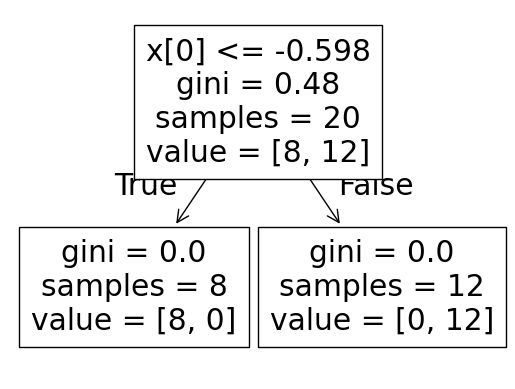

In [35]:
plot_tree(clf1)

[Text(0.6, 0.8333333333333334, 'x[0] <= -0.063\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.4, 0.5, 'x[4] <= 1.419\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.7, 0.6666666666666667, '  False')]

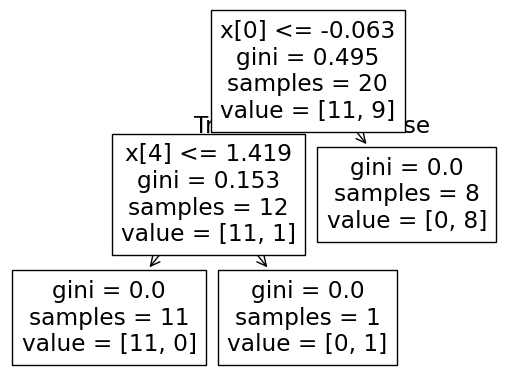

In [36]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[0] <= -0.078\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.4, 0.5, 'x[4] <= 1.185\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.7, 0.6666666666666667, '  False')]

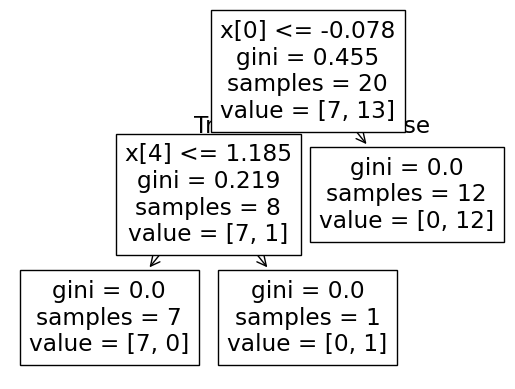

In [37]:
plot_tree(clf3)

In [42]:
clf1.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312, -0.224551]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [43]:
clf2.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312, -0.224551]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [44]:
clf3.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312, -0.224551]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

**Using the row sampling methdod, trained three models, then checked for the result, since all three shows 1, the result is one. We take the majority but here all three model made same prediction. I have taken the data from the df2 dataframe and the value of target there was 1. Therefore, the model is working well.**

In [53]:
df4=sample_features(df,0.8)
print(df4)

        col5      col3      col1      col4  target
0   0.786464 -0.686603 -0.994291 -0.972833       0
1  -1.605604 -0.085436  1.605922  0.339301       1
2   3.169062 -3.494993  1.318064 -1.427813       0
3  -1.933297  3.093970  0.967636  2.716696       1
4   1.850031 -2.630729 -0.045843 -0.472760       0
..       ...       ...       ...       ...     ...
95  1.711509 -1.376862 -0.222708 -0.461880       0
96  2.376010 -3.255565  1.098774 -0.602417       0
97 -1.102349  0.003232  0.649627 -2.003429       1
98 -1.532478  4.455861 -1.557939 -3.698351       1
99  1.351666 -0.022962 -1.593362 -2.405918       0

[100 rows x 5 columns]


/tmp/ipykernel_770/2897883026.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [48]:
df5=sample_features(df,0.8)

In [49]:
df6=sample_features(df,0.8)

In [58]:
from sklearn.tree import DecisionTreeClassifier
clf4=DecisionTreeClassifier()
clf5=DecisionTreeClassifier()
clf6=DecisionTreeClassifier()

clf4.fit(df4.iloc[:,0:4], df4.iloc[:,-1])
clf5.fit(df5.iloc[:,0:4], df5.iloc[:,-1])
clf6.fit(df6.iloc[:,0:4], df6.iloc[:,-1])

from sklearn.tree import plot_tree

[Text(0.625, 0.9, 'x[0] <= 0.386\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.4166666666666667, 0.7, 'x[2] <= 0.511\ngini = 0.335\nsamples = 61\nvalue = [13, 48]'),
 Text(0.5208333333333334, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[1] <= 1.148\ngini = 0.496\nsamples = 22\nvalue = [12, 10]'),
 Text(0.16666666666666666, 0.3, 'x[3] <= -1.45\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.08333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.5833333333333334, 0.5, 'x[1] <= -2.674\ngini = 0.05\nsamples = 39\nvalue = [1, 38]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 38\nvalue = [0, 38]'),
 Text(0.8333333333333334, 0.7, 'x[1] <= 1.049\ngini = 0.097\nsamples = 39\nvalue = [37, 2]'),
 Text(0.7291666666666667, 0.8, '  False'),
 Text(0.75, 0.5, 'gini =

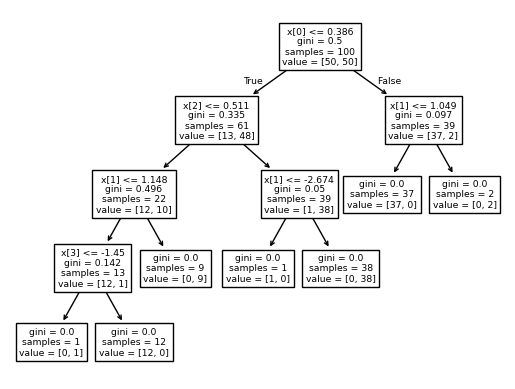

In [59]:
plot_tree(clf4)

[Text(0.5277777777777778, 0.9285714285714286, 'x[0] <= 0.415\ngini = 0.5\nsamples = 80\nvalue = [39, 41]'),
 Text(0.3333333333333333, 0.7857142857142857, 'x[1] <= 1.128\ngini = 0.303\nsamples = 43\nvalue = [35, 8]'),
 Text(0.4305555555555556, 0.8571428571428572, 'True  '),
 Text(0.2777777777777778, 0.6428571428571429, 'x[1] <= 0.183\ngini = 0.48\nsamples = 20\nvalue = [12, 8]'),
 Text(0.1111111111111111, 0.5, 'x[3] <= 1.085\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.05555555555555555, 0.35714285714285715, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[3] <= 2.058\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.1111111111111111, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2222222222222222, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4444444444444444, 0.5, 'x[2] <= 1.181\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.3888888888888889, 0.35714285714285715, 'x[1

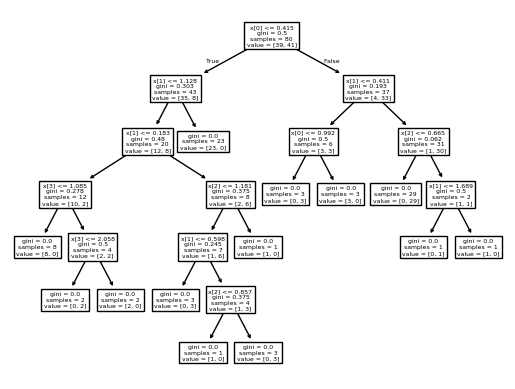

In [60]:
plot_tree(clf5)

[Text(0.625, 0.9285714285714286, 'x[0] <= 0.615\ngini = 0.462\nsamples = 80\nvalue = [51, 29]'),
 Text(0.4166666666666667, 0.7857142857142857, 'x[3] <= 2.396\ngini = 0.27\nsamples = 56\nvalue = [47, 9]'),
 Text(0.5208333333333334, 0.8571428571428572, 'True  '),
 Text(0.25, 0.6428571428571429, 'x[3] <= -1.822\ngini = 0.15\nsamples = 49\nvalue = [45.0, 4.0]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= -0.78\ngini = 0.117\nsamples = 48\nvalue = [45, 3]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[3] <= 0.744\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.35714285714285715, 'x[3] <= -0.752\ngini = 0.049\nsamples = 40\nvalue = [39, 1]'),
 Text(0.4166666666666667, 0.21428571428571427, 'x[3] <= -1.462\ngini = 0.375\nsamples = 4\nvalu

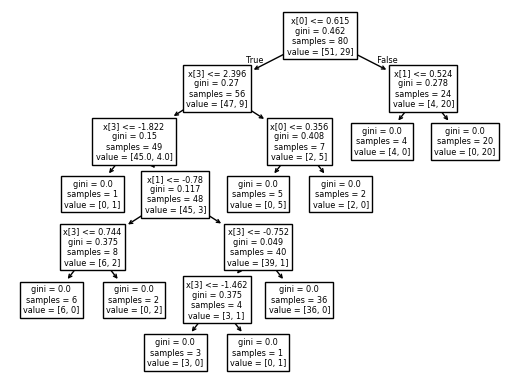

In [61]:
plot_tree(clf6)

In [63]:
clf4.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312,]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [64]:
clf5.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312,]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [65]:
clf6.predict(np.array([0.932107, -1.130502,  3.429498, -1.618312,]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**Using the features sampling methdod, trained three models, then checked for the result, since two model predicted the target to be 0, we go with the majority so the result is 0**

In [68]:
df7=combined_sampling(df,0.5,0.5)

/tmp/ipykernel_770/2897883026.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [69]:
df8=combined_sampling(df,0.5,0.5)
print(df8)

        col5      col3  target
35 -1.671372 -0.730357       1
43  0.251959  4.866463       1
22  0.792260 -0.307294       0
35 -1.671372 -0.730357       1
86  0.227828 -0.660350       0
22  0.792260 -0.307294       0
42 -0.680723 -0.219963       1
16 -0.449668 -1.391329       0
58  0.574630 -1.500348       0
31 -0.788675 -0.687664       1
65  0.490174 -1.564550       0
0   0.786464 -0.686603       0
59 -0.428942 -0.706490       1
34  0.646191 -0.812232       0
6  -2.570233 -1.052082       1
94  0.815986  1.796752       1
17  1.069037 -0.519102       0
42 -0.680723 -0.219963       1
49 -2.855892  0.505896       1
39 -2.933430  1.916548       1
64 -0.742617  2.739268       1
59 -0.428942 -0.706490       1
85  1.637880 -1.925780       0
17  1.069037 -0.519102       0
10  0.053288  2.005378       1
44  3.578459 -0.322359       0
17  1.069037 -0.519102       0
64 -0.742617  2.739268       1
43  0.251959  4.866463       1
92  3.457173 -1.971964       0
58  0.574630 -1.500348       0
71 -0.10

/tmp/ipykernel_770/2897883026.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [70]:
df9=combined_sampling(df,0.5,0.5)

/tmp/ipykernel_770/2897883026.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [71]:
from sklearn.tree import DecisionTreeClassifier
clf7=DecisionTreeClassifier()
clf8=DecisionTreeClassifier()
clf9=DecisionTreeClassifier()

clf7.fit(df7.iloc[:,0:2], df7.iloc[:,-1])
clf8.fit(df8.iloc[:,0:2], df8.iloc[:,-1])
clf9.fit(df9.iloc[:,0:2], df9.iloc[:,-1])

from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[1] <= 0.528\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.4, 0.5, 'x[0] <= 1.777\ngini = 0.08\nsamples = 24\nvalue = [23, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.7, 0.6666666666666667, '  False')]

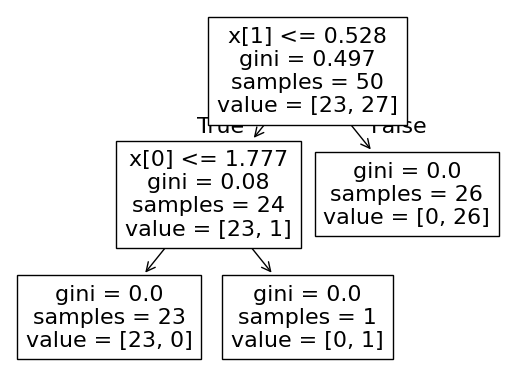

In [72]:
plot_tree(clf7)

[Text(0.5, 0.8333333333333334, 'x[0] <= -0.409\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.25, 0.5, 'x[1] <= -1.222\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.75, 0.5, 'x[1] <= 1.113\ngini = 0.298\nsamples = 33\nvalue = [27, 6]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 27\nvalue = [27, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

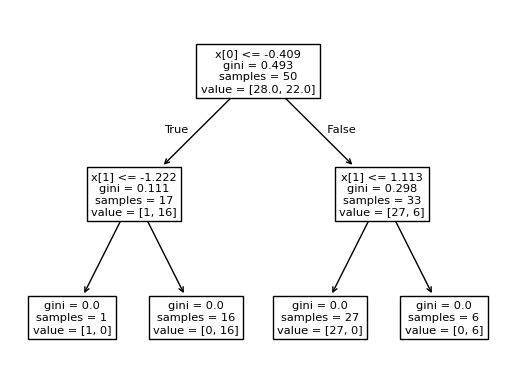

In [73]:
plot_tree(clf8)

[Text(0.625, 0.9, 'x[0] <= 0.1\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.4166666666666667, 0.7, 'x[0] <= -0.399\ngini = 0.191\nsamples = 28\nvalue = [3, 25]'),
 Text(0.5208333333333334, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[1] <= -0.661\ngini = 0.083\nsamples = 23\nvalue = [1, 22]'),
 Text(0.16666666666666666, 0.3, 'x[1] <= -1.091\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.08333333333333333, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.5833333333333334, 0.5, 'x[1] <= 1.804\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8333333333333334, 0.7, 'x[1] <= 1.935\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.7291666666666667, 0.8, '  False'),
 Text(0.75, 0.5, 'gini = 0.0\nsa

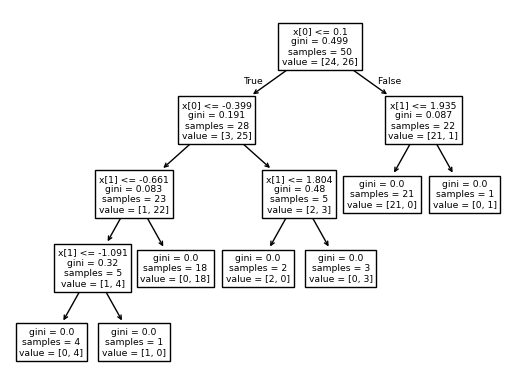

In [74]:
plot_tree(clf9)

In [75]:
clf7.predict(np.array([0.932107, -1.130502]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [76]:
clf8.predict(np.array([0.932107, -1.130502]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [77]:
clf9.predict(np.array([0.932107, -1.130502]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**Using the combined sampling methdod, trained three models, then checked for the result, since all three model predicted the result as 0, the target is 0 for the data given**